1- Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np

# بارگذاری دیتاست (این لینک مستقیم به دیتاست در گیت‌هاب است)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# نمایش ۵ ردیف اول
print("First 5 rows of the dataset:")
display(df.head())

# بررسی اطلاعات کلی (نوع داده‌ها و مقادیر خالی)
print("\nDataset Info:")
df.info()

# بررسی آماری ستون‌های عددی
print("\nNumerical Summary:")
display(df.describe())


First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


2- Data Cleaning

In [2]:
# ۱. تبدیل ستون TotalCharges به عدد
# errors='coerce' باعث میشه اگر کاراکتر غیرعددی (مثل فاصله) دید، اون رو به NaN تبدیل کنه
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ۲. بررسی اینکه چند تا مقدار خالی (NaN) ایجاد شد
missing_total_charges = df['TotalCharges'].isnull().sum()
print(f"Number of missing values in TotalCharges: {missing_total_charges}")

# ۳. حذف ردیف‌هایی که TotalCharges آن‌ها خالی است (چون تعدادشون کمه)
df.dropna(subset=['TotalCharges'], inplace=True)

# ۴. حذف ستون customerID چون در مدل‌سازی تاثیری نداره
df.drop('customerID', axis=1, inplace=True)

# ۵. تبدیل SeniorCitizen به متن برای تحلیل راحت‌تر (Optional)
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("\nCleaning Done! New Info:")
df.info()


Number of missing values in TotalCharges: 11

Cleaning Done! New Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 

3-  Exploratory Data Analysis (EDA) - Visuals

C:\Users\Admin-IT\AppData\Local\Temp\ipykernel_22432\2702433891.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


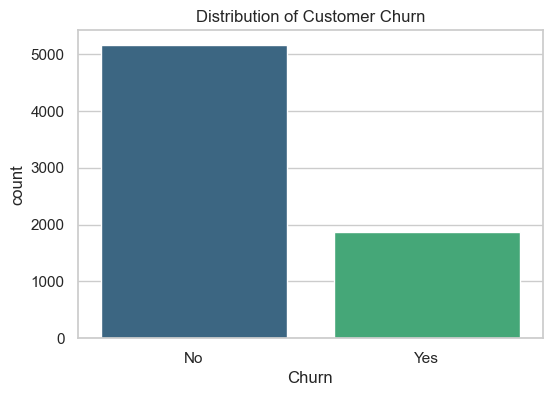

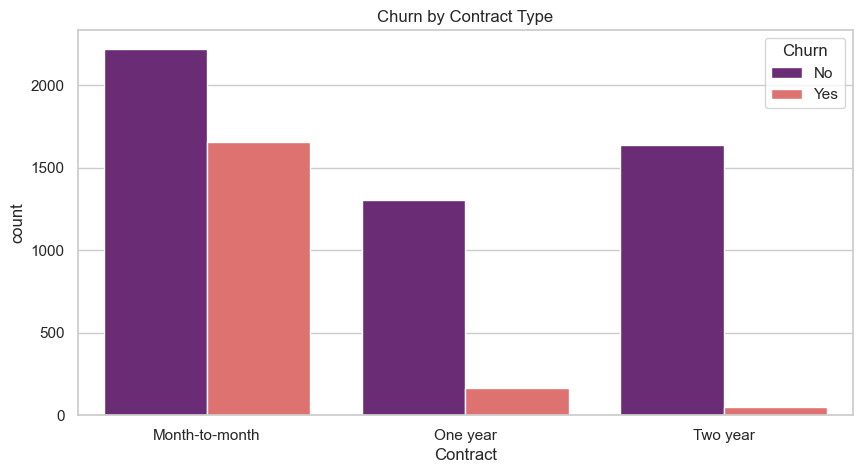

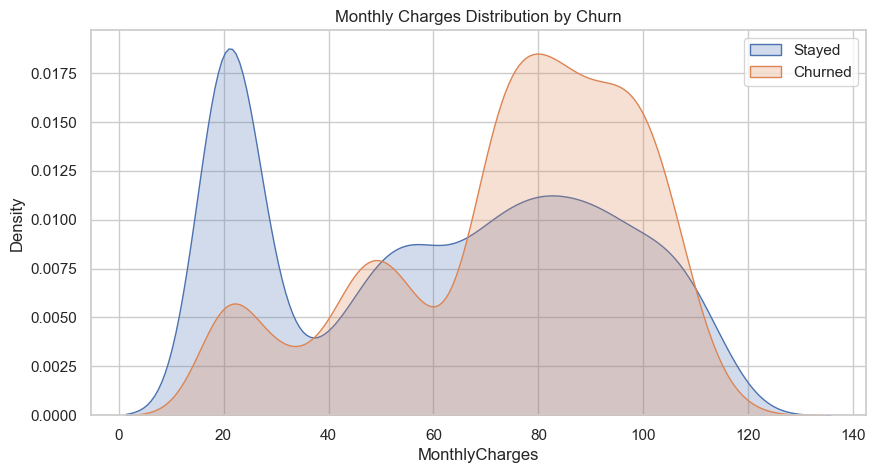

In [4]:
# ایجاد پوشه برای ذخیره نمودارها (اگر وجود ندارد)
import os
if not os.path.exists('images'):
    os.makedirs('images')

# ۱. ذخیره توزیع Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.savefig('images/1_churn_distribution.png', dpi=300, bbox_inches='tight') # ذخیره با کیفیت بالا
plt.show()

# ۲. ذخیره تحلیل قرارداد
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn by Contract Type')
plt.savefig('images/2_churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

# ۳. ذخیره تحلیل هزینه‌های ماهانه
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Stayed', fill=True)
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churned', fill=True)
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.savefig('images/3_monthly_charges_dist.png', dpi=300, bbox_inches='tight')
plt.show()


4- Service analysis

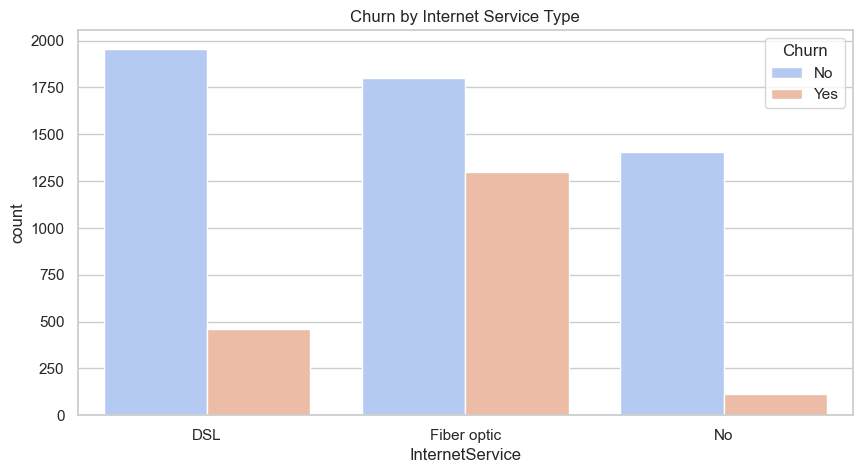

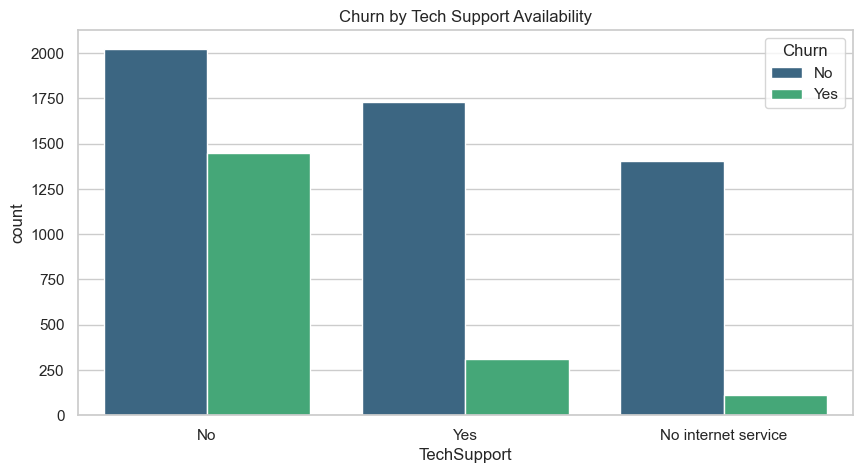

In [6]:
# ۴. تحلیل نوع سرویس اینترنت
plt.figure(figsize=(10, 5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='coolwarm')
plt.title('Churn by Internet Service Type')
# ذخیره در پوشه images با نام مرحله ۴
plt.savefig('images/4_churn_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()

# ۵. تحلیل پشتیبانی فنی
plt.figure(figsize=(10, 5))
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='viridis')
plt.title('Churn by Tech Support Availability')
# ذخیره در پوشه images با نام مرحله ۵
plt.savefig('images/5_churn_by_tech_support.png', dpi=300, bbox_inches='tight')
plt.show()



5- Encoding

In [7]:
# تبدیل ستون هدف (Churn) به عدد: Yes=1 , No=0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# تبدیل بقیه ستون‌های متنی به اعداد (One-Hot Encoding)
# این کار برای ستون‌هایی مثل نوع اینترنت و قرارداد انجام می‌شود
df_encoded = pd.get_dummies(df)

# چک کردن ۵ سطر اول دیتای جدید
print(df_encoded.head())


   tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  gender_Male  \
0       1           29.85         29.85      0           True        False   
1      34           56.95       1889.50      0          False         True   
2       2           53.85        108.15      1          False         True   
3      45           42.30       1840.75      0          False         True   
4       2           70.70        151.65      1           True        False   

   SeniorCitizen_No  SeniorCitizen_Yes  Partner_No  Partner_Yes  ...  \
0              True              False       False         True  ...   
1              True              False        True        False  ...   
2              True              False        True        False  ...   
3              True              False        True        False  ...   
4              True              False        True        False  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False      

6- Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

# ۱. تعیین ویژگی‌ها (X) و هدف (y)
# هدف ما پیش‌بینی Churn است، پس آن را از X حذف می‌کنیم
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# ۲. تقسیم دیتا به ۸۰٪ آموزش و ۲۰٪ تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (5625, 46)
Testing set size: (1407, 46)


7-  Random Forest

In [9]:
# Step 7: Train Random Forest Model and Evaluate Performance

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. ساخت مدل
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. آموزش مدل با داده‌های آموزش
rf_model.fit(X_train, y_train)

# 3. پیش‌بینی روی داده‌های تست
y_pred = rf_model.predict(X_test)

# 4. محاسبه دقت مدل
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# 5. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.7874911158493249

Confusion Matrix:
[[932 101]
 [198 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



 8-  Feature Importance

                           Feature  Importance
2                     TotalCharges    0.152012
0                           tenure    0.141601
1                   MonthlyCharges    0.137075
37         Contract_Month-to-month    0.053648
19               OnlineSecurity_No    0.032442
44  PaymentMethod_Electronic check    0.027586
28                  TechSupport_No    0.026416
17     InternetService_Fiber optic    0.023188
39               Contract_Two year    0.019649
22                 OnlineBackup_No    0.019282


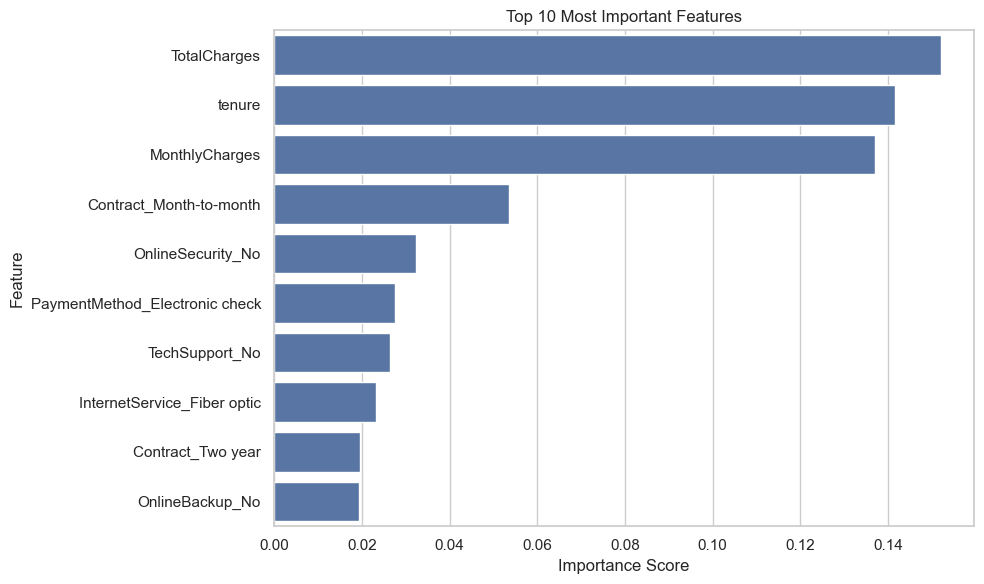

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# استخراج Feature Importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# مرتب سازی
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# انتخاب 10 ویژگی مهم
top10 = feature_importance_df.head(10)

print(top10)

# رسم نمودار
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Importance', y='Feature')

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()

# ✅ ذخیره تصویر
plt.savefig("images/6_feature_importance.png", dpi=300, bbox_inches='tight')


plt.show()


9- ROC Curve & AUC Score

AUC Score: 0.8118286388743653


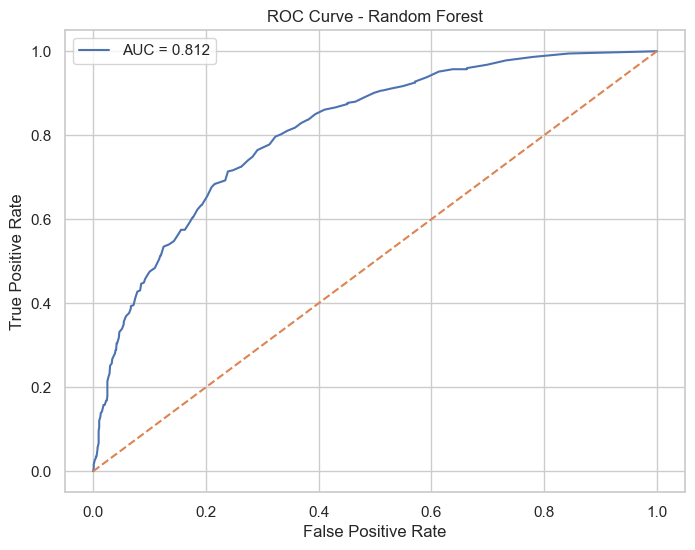

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# احتمال churn
y_prob = rf_model.predict_proba(X_test)[:,1]

# محاسبه ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# محاسبه AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# رسم نمودار
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

# ✅ اول ذخیره
plt.savefig("images/7_ROC_curve.png", dpi=300, bbox_inches='tight')


# بعد نمایش
plt.show()



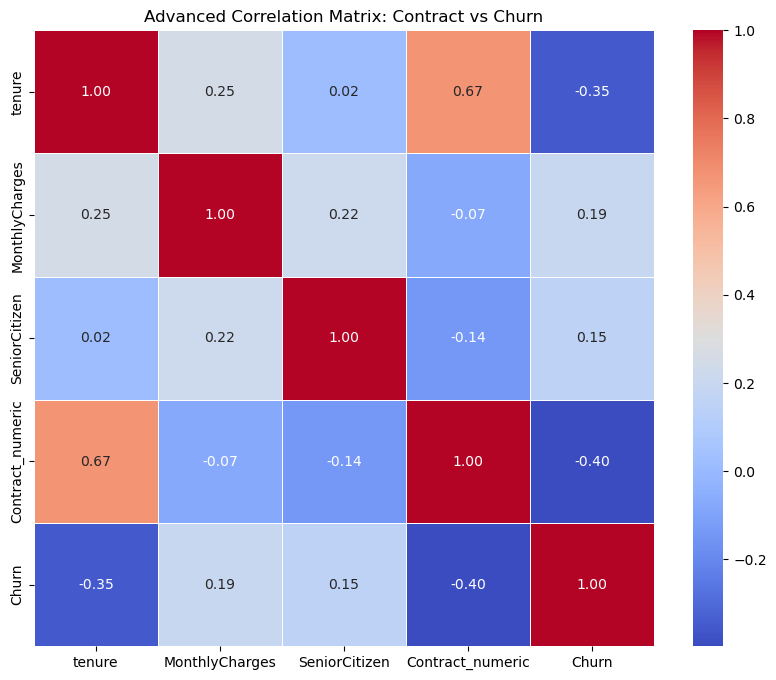

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

if not os.path.exists('images'):
    os.makedirs('images')

df = pd.read_csv('telco_churn.csv')

# ۱. تبدیل Churn به عدد
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ۲. تبدیل Contract به عدد (بر اساس اعتبار و پایداری)
# Month-to-month کمترین پایداری (0) و Two year بیشترین پایداری (2)
df['Contract_numeric'] = df['Contract'].map({
    'Month-to-month': 0, 
    'One year': 1, 
    'Two year': 2
})

# ۳. انتخاب ستون‌های مهم برای دیدن رابطه واقعی
cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Contract_numeric', 'Churn']
corr = df[cols].corr()

# ۴. رسم Heatmap حرفه‌ای
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Advanced Correlation Matrix: Contract vs Churn')

plt.savefig('images/9_advanced_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
